In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

In [12]:
from collections import deque

## Data Demostartion

In [3]:
df = pd.read_csv('Data/Raw_data/IM2606_20260514.csv', usecols=[0] + list(range(5, 25)))
df

,timestamp,bid1,bid2,bid3,bid4,bid5,ask1,ask2,ask3,ask4,...,bidSize1,bidSize2,bidSize3,bidSize4,bidSize5,askSize1,askSize2,askSize3,askSize4,askSize5
0,20260514 09:29:00.292932,8891.0,8890.4,8890.2,8890.0,8889.6,8891.4,8892.0,8893.0,8893.2,...,1.0,1.0,1.0,3.0,1.0,15.0,7.0,1.0,1.0,1.0
1,20260514 09:30:00.233226,8892.0,8891.6,8891.4,8891.2,8891.0,8898.0,8898.8,8899.0,8899.4,...,1.0,16.0,31.0,2.0,9.0,7.0,2.0,28.0,2.0,6.0
2,20260514 09:30:00.734494,8894.0,8893.8,8893.4,8893.2,8893.0,8895.4,8896.8,8897.2,8897.4,...,1.0,1.0,7.0,5.0,6.0,1.0,1.0,2.0,2.0,1.0
3,20260514 09:30:01.235377,8892.2,8892.0,8891.6,8891.4,8891.2,8893.2,8894.4,8896.6,8897.4,...,10.0,54.0,24.0,69.0,3.0,2.0,6.0,2.0,2.0,4.0
4,20260514 09:30:01.733066,8893.6,8893.2,8893.0,8892.0,8891.6,8895.4,8897.6,8898.0,8898.4,...,1.0,4.0,1.0,49.0,24.0,1.0,4.0,7.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28624,20260514 14:59:58.286068,8689.6,8689.4,8689.0,8688.8,8688.6,8689.8,8690.0,8690.4,8690.6,...,2.0,1.0,6.0,3.0,1.0,2.0,1.0,1.0,1.0,5.0
28625,20260514 14:59:58.783357,8689.8,8689.0,8688.8,8688.6,8688.2,8690.8,8691.0,8691.2,8691.6,...,6.0,5.0,3.0,1.0,6.0,4.0,7.0,60.0,1.0,1.0
28626,20260514 14:59:59.282670,8689.8,8689.0,8688.8,8688.6,8688.2,8690.8,8691.0,8691.2,8691.6,...,4.0,5.0,3.0,1.0,6.0,4.0,7.0,60.0,1.0,1.0
28627,20260514 14:59:59.784513,8689.8,8689.0,8688.8,8688.6,8688.2,8690.0,8690.8,8691.0,8691.2,...,3.0,5.0,3.0,1.0,6.0,1.0,3.0,7.0,60.0,1.0


In [4]:
df['MidPrice'] = (df['bid1'] + df['ask1']) / 2
df['MidPrice']

0        8891.2
1        8895.0
2        8894.7
3        8892.7
4        8894.5
          ...  
28624    8689.7
28625    8690.3
28626    8690.3
28627    8689.9
28628    8689.9
Name: MidPrice, Length: 28629, dtype: float64

In [5]:
for i in range(1,6):
    df[f'askcumSize{i}'] = df[f'askSize{i}'] + (df[f'askcumSize{i-1}'] if i != 1 else 0)
    df[f'bidcumSize{i}'] = df[f'bidSize{i}'] + (df[f'bidcumSize{i-1}'] if i != 1 else 0)
df.head()

,timestamp,bid1,bid2,bid3,bid4,bid5,ask1,ask2,ask3,ask4,...,askcumSize1,bidcumSize1,askcumSize2,bidcumSize2,askcumSize3,bidcumSize3,askcumSize4,bidcumSize4,askcumSize5,bidcumSize5
0,20260514 09:29:00.292932,8891.0,8890.4,8890.2,8890.0,8889.6,8891.4,8892.0,8893.0,8893.2,...,15.0,1.0,22.0,2.0,23.0,3.0,24.0,6.0,25.0,7.0
1,20260514 09:30:00.233226,8892.0,8891.6,8891.4,8891.2,8891.0,8898.0,8898.8,8899.0,8899.4,...,7.0,1.0,9.0,17.0,37.0,48.0,39.0,50.0,45.0,59.0
2,20260514 09:30:00.734494,8894.0,8893.8,8893.4,8893.2,8893.0,8895.4,8896.8,8897.2,8897.4,...,1.0,1.0,2.0,2.0,4.0,9.0,6.0,14.0,7.0,20.0
3,20260514 09:30:01.235377,8892.2,8892.0,8891.6,8891.4,8891.2,8893.2,8894.4,8896.6,8897.4,...,2.0,10.0,8.0,64.0,10.0,88.0,12.0,157.0,16.0,160.0
4,20260514 09:30:01.733066,8893.6,8893.2,8893.0,8892.0,8891.6,8895.4,8897.6,8898.0,8898.4,...,1.0,1.0,5.0,5.0,12.0,6.0,13.0,55.0,14.0,79.0


In [6]:
def price_micro(df, level: int):
    price_cols = [f'bid{level}', f'ask{level}']
    size_cols = [f'bidcumSize{level}', f'askcumSize{level}']   
    df[f'price_micro_{level}'] = (df[price_cols[0]] * df[size_cols[1]] + df[price_cols[1]] * df[size_cols[0]]) / (df[size_cols[0]] + df[size_cols[1]])
    return None

In [7]:
for i in range(1,6):
    price_micro(df, level = i)
df

,timestamp,bid1,bid2,bid3,bid4,bid5,ask1,ask2,ask3,ask4,...,bidcumSize3,askcumSize4,bidcumSize4,askcumSize5,bidcumSize5,price_micro_1,price_micro_2,price_micro_3,price_micro_4,price_micro_5
0,20260514 09:29:00.292932,8891.0,8890.4,8890.2,8890.0,8889.6,8891.4,8892.0,8893.0,8893.2,...,3.0,24.0,6.0,25.0,7.0,8891.025000,8890.533333,8890.523077,8890.640000,8890.562500
1,20260514 09:30:00.233226,8892.0,8891.6,8891.4,8891.2,8891.0,8898.0,8898.8,8899.0,8899.4,...,48.0,39.0,50.0,45.0,59.0,8892.750000,8896.307692,8895.691765,8895.806742,8895.878846
2,20260514 09:30:00.734494,8894.0,8893.8,8893.4,8893.2,8893.0,8895.4,8896.8,8897.2,8897.4,...,9.0,6.0,14.0,7.0,20.0,8894.700000,8895.300000,8896.030769,8896.140000,8896.703704
3,20260514 09:30:01.235377,8892.2,8892.0,8891.6,8891.4,8891.2,8893.2,8894.4,8896.6,8897.4,...,88.0,12.0,157.0,16.0,160.0,8893.033333,8894.133333,8896.089796,8896.973964,8897.381818
4,20260514 09:30:01.733066,8893.6,8893.2,8893.0,8892.0,8891.6,8895.4,8897.6,8898.0,8898.4,...,6.0,13.0,55.0,14.0,79.0,8894.500000,8895.400000,8894.666667,8897.176471,8897.546237
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28624,20260514 14:59:58.286068,8689.6,8689.4,8689.0,8688.8,8688.6,8689.8,8690.0,8690.4,8690.6,...,9.0,5.0,12.0,10.0,13.0,8689.700000,8689.700000,8689.969231,8690.070588,8689.843478
28625,20260514 14:59:58.783357,8689.8,8689.0,8688.8,8688.6,8688.2,8690.8,8691.0,8691.2,8691.6,...,14.0,72.0,15.0,73.0,21.0,8690.400000,8690.000000,8689.195294,8689.117241,8689.004255
28626,20260514 14:59:59.282670,8689.8,8689.0,8688.8,8688.6,8688.2,8690.8,8691.0,8691.2,8691.6,...,12.0,72.0,13.0,73.0,19.0,8690.300000,8689.900000,8689.146988,8689.058824,8688.943478
28627,20260514 14:59:59.784513,8689.8,8689.0,8688.8,8688.6,8688.2,8690.0,8690.8,8691.0,8691.2,...,11.0,71.0,12.0,72.0,18.0,8689.950000,8690.200000,8689.900000,8688.975904,8688.880000


In [8]:
df_selected = pd.concat([df.iloc[:, [0]], df.iloc[:, -6:]], axis=1)
m_plus_t = df_selected['MidPrice'].rolling(window=10).mean().shift(-10)
df_selected['price_move_smooth'] = m_plus_t - df_selected['MidPrice']
df_selected['price_move'] = (df_selected['MidPrice'].shift(-10) - df_selected['MidPrice'])
df_selected['price_move_smooth_pctg'] = df_selected['price_move_smooth'] / df_selected['MidPrice']
df_selected['price_move_pctg'] = df_selected['price_move'] / df_selected['MidPrice']
df_selected

KeyError: 'MidPrice'

upper bond: 0.01000000%, lower bond: -0.01000000%


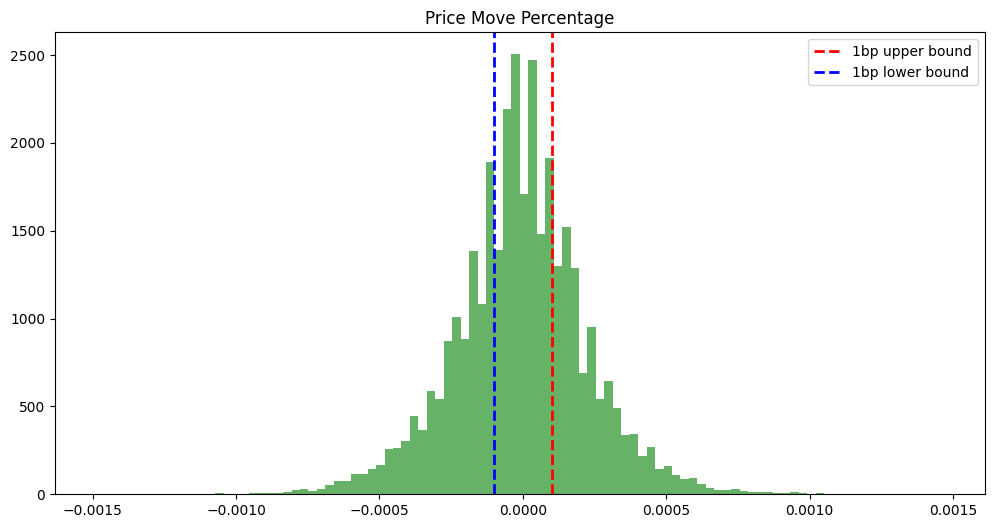

In [ ]:
# Calculate percentiles
p_upper = 0.0001
p_lower = -0.0001
print(f"upper bond: {p_upper*100:0.8f}%, lower bond: {p_lower*100:0.8f}%")
plt.figure(figsize=(12, 6))
plt.hist(df_selected['price_move_pctg'], bins=100, density=True, alpha=0.6, color='g')
plt.axvline(x=p_upper, color='r', linestyle='--', linewidth=2, label=f'1bp upper bound')
plt.axvline(x=p_lower, color='b', linestyle='--', linewidth=2, label=f'1bp lower bound')
plt.title('Price Move Percentage')
plt.legend()
plt.show()

upper bond: 0.01%, lower bond: -0.01%


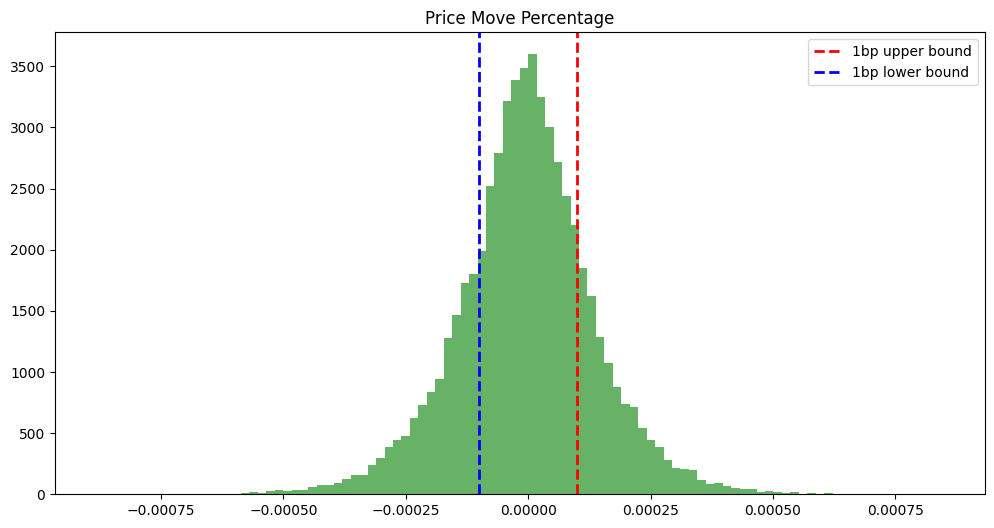

In [ ]:
# Calculate percentiles
p_upper = 0.0001
p_lower = -0.0001
print(f"upper bond: {p_upper*100}%, lower bond: {p_lower*100}%")
plt.figure(figsize=(12, 6))
plt.hist(df_selected['price_move_smooth_pctg'], bins=100, density=True, alpha=0.6, color='g')
plt.axvline(x=p_upper, color='r', linestyle='--', linewidth=2, label=f'1bp upper bound')
plt.axvline(x=p_lower, color='b', linestyle='--', linewidth=2, label=f'1bp lower bound')
plt.title('Price Move Percentage')
plt.legend()
plt.show()

In [ ]:
def move_label(x, alpha = 0.0002):
    if x > alpha:
        return 1
    elif x < -alpha:
        return -1
    else:
        return 0

In [ ]:
alpha = 0.0001
df_selected['price_move_label'] = df_selected['price_move_pctg'].apply(lambda x: move_label(x, alpha))
df_selected['price_move_label'].value_counts(normalize=True)

price_move_label
 0    0.385483
-1    0.318349
 1    0.296168
Name: proportion, dtype: float64

In [ ]:
df_selected['price_move_label'].value_counts().values

array([16053,  6540,  6140])

In [ ]:
from pathlib import Path
base_path = Path('Data/Normalized_data')
csv_files = sorted(base_path.glob('normalized_*.csv'))
print(f"Found {len(csv_files)} CSV files to merge.")

def load_and_transform(file):
    df = pd.read_csv(file)
    # 你的逻辑：标签 + 1
    df['price_move_label'] = df['price_move_label'] + 1
    return df

data_frames = [load_and_transform(f) for f in csv_files]

big_df = pd.concat(data_frames, ignore_index=True)
big_df.info()

Found 10 CSV files to merge.
<class 'pandas.DataFrame'>
RangeIndex: 284180 entries, 0 to 284179
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   price_micro_1     284180 non-null  float64
 1   price_micro_2     284180 non-null  float64
 2   price_micro_3     284180 non-null  float64
 3   price_micro_4     284180 non-null  float64
 4   price_micro_5     284180 non-null  float64
 5   price_move_label  284180 non-null  int64  
dtypes: float64(5), int64(1)
memory usage: 13.0 MB


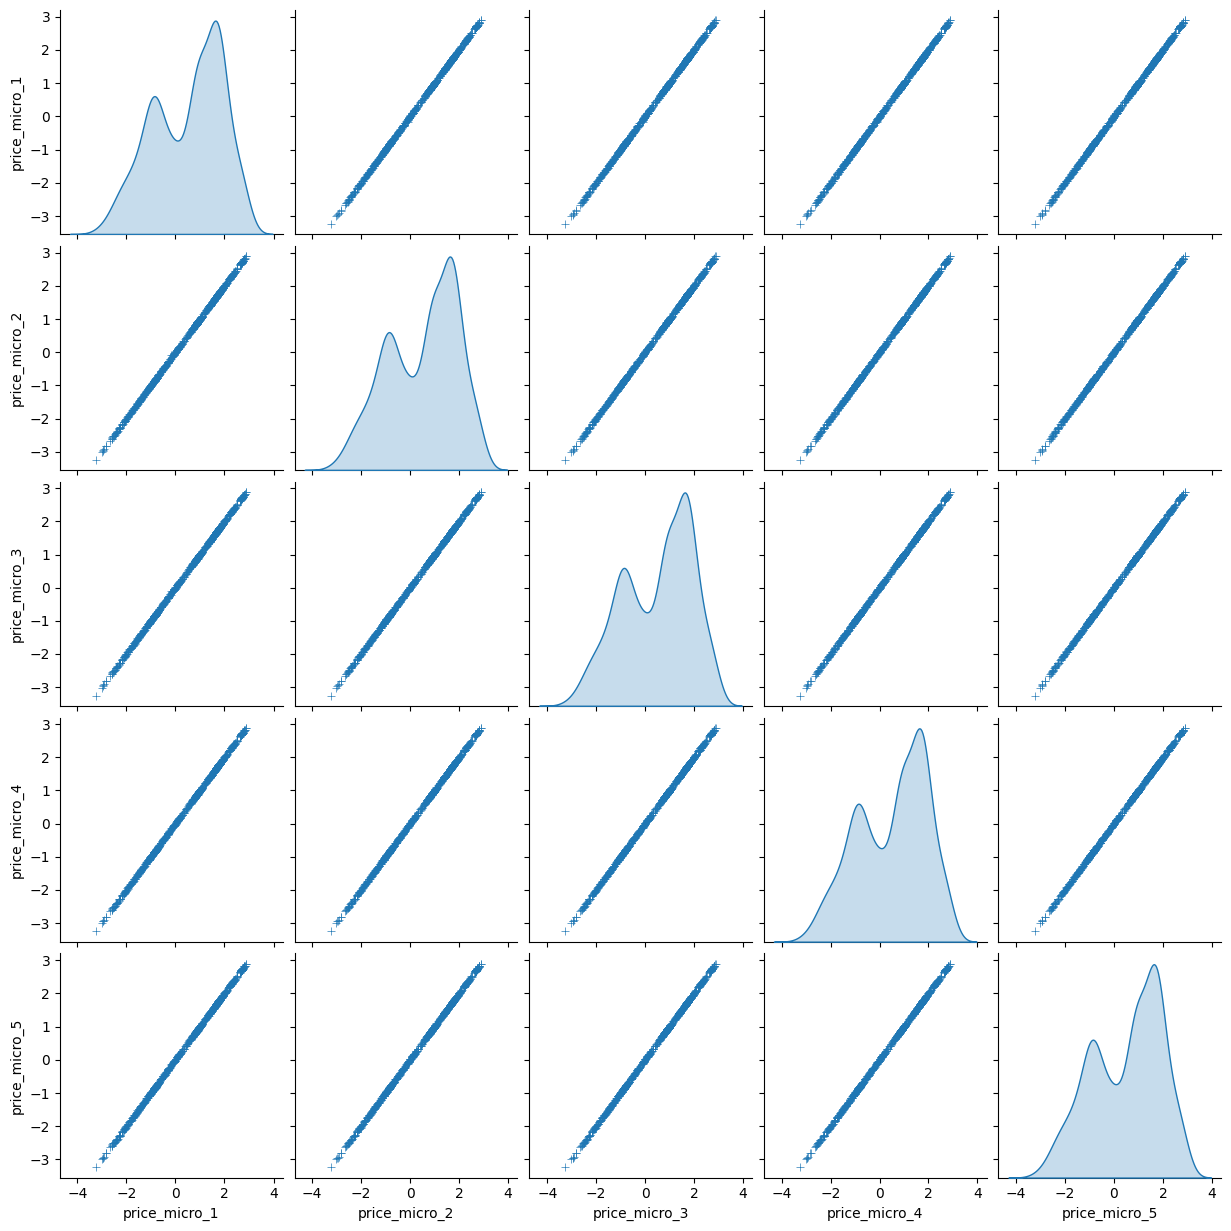

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

feature_cols = [col for col in big_df.columns if col.startswith('price_micro')] 
df_subset = big_df[feature_cols].sample(n=1000, random_state=42)

# 2. 绘制 Pair Scatter
# hue 参数可以指定按类别上色，如果你有分类标签的话
sns.pairplot(df_subset, diag_kind='kde', markers='+')

奇异值 (Singular Values): [1.82922305e+03 3.60430400e+00 1.85642339e+00 1.35553463e+00
 1.10567301e+00]


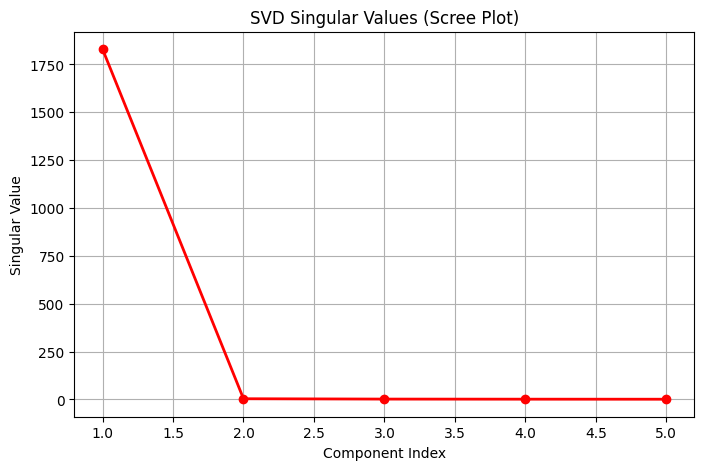

In [ ]:
features = big_df[feature_cols].values

# SVD
U, S, Vt = np.linalg.svd(features, full_matrices=False)

# 3. 打印奇异值
print("奇异值 (Singular Values):", S)

# 4. 绘制“陡坡图” (Scree Plot)
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(S) + 1), S, 'o-', linewidth=2, color='r')
plt.title('SVD Singular Values (Scree Plot)')
plt.xlabel('Component Index')
plt.ylabel('Singular Value')
plt.grid(True)
plt.show()

## CNN Structure

In [7]:
from process_data import process_data, window_normalize
from pathlib import Path

In [13]:
inputpath = 'Data/Raw_data/'
outputpath = 'Data/Processed_data/'
path = Path(outputpath)
path.mkdir(parents=True, exist_ok=True)
alpha = 0.00005
FE = False

raw_files = list(Path(inputpath).glob('*.csv'))

for raw_file in raw_files:
    print(f'Processing file:{raw_file.name}')
    outputfile = f'{outputpath}processed_{raw_file.stem[-4:]}.csv'
    process_data(raw_file, outputfile, label_method='l2', FE = FE, alpha = alpha)

inputpath_normalized = 'Data/Processed_data/'
outputpath_normalized = 'Data/Normalized_data/' 
path = Path(outputpath_normalized)
path.mkdir(parents=True, exist_ok=True)
window_normalize(inputpath_normalized, outputpath_normalized, FE = FE, window_size = 5)

Processing file:IM2606_20260401.csv
Data processing completed. Processed data saved to Data/Processed_data/processed_0401.csv.
Processing file:IM2606_20260402.csv
Data processing completed. Processed data saved to Data/Processed_data/processed_0402.csv.
Processing file:IM2606_20260403.csv
Data processing completed. Processed data saved to Data/Processed_data/processed_0403.csv.
Processing file:IM2606_20260407.csv
Data processing completed. Processed data saved to Data/Processed_data/processed_0407.csv.
Processing file:IM2606_20260408.csv
Data processing completed. Processed data saved to Data/Processed_data/processed_0408.csv.
Processing file:IM2606_20260409.csv
Data processing completed. Processed data saved to Data/Processed_data/processed_0409.csv.
Processing file:IM2606_20260410.csv
Data processing completed. Processed data saved to Data/Processed_data/processed_0410.csv.
Processing file:IM2606_20260413.csv
Data processing completed. Processed data saved to Data/Processed_data/proc

In [2]:
from DeepLOB import create_dataloader, DeepLOB, train_model, validate_engine, EarlyStopping

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR

In [ ]:
data = pd.read_csv('Data/Normalized_data/normalized_0515.csv')
data

,ask1,askSize1,bid1,bidSize1,ask2,askSize2,bid2,bidSize2,ask3,askSize3,...,bidSize3,ask4,askSize4,bid4,bidSize4,ask5,askSize5,bid5,bidSize5,price_move_label
0,0.054862,-0.411044,0.061485,-0.210402,0.067295,1.146322,0.039726,1.146292,0.068084,-0.358750,...,1.298213,0.075184,0.066658,0.041101,3.609268,0.072988,-0.354470,0.043267,-0.469237,1
1,0.036235,0.172426,0.024237,0.515513,0.039356,-0.205554,0.027309,-0.493275,0.037041,-0.358750,...,3.327776,0.041038,0.216943,0.028683,-0.480116,0.048155,-0.094904,0.015322,-0.082001,1
2,0.011400,-0.022064,0.018030,-0.210402,0.020731,-0.355763,0.017997,-0.493275,0.021520,-0.070908,...,1.298213,0.022413,-0.083626,-0.002364,5.040553,0.023322,-0.354470,-0.003307,-0.469237,1
3,0.048653,0.561406,0.024237,0.273541,0.045565,-0.055346,0.027309,1.848964,0.043249,-0.358750,...,-0.280336,0.041038,0.667797,0.028683,-0.480116,0.045051,-0.094904,0.009112,1.079708,1
4,0.051757,0.950386,0.042861,-0.210402,0.048669,-0.355763,0.039726,-0.493275,0.046354,0.648695,...,2.876762,0.050351,-0.083626,0.041101,1.973515,0.048155,0.034880,0.043267,0.305236,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28699,-2.198931,-0.411044,-2.195083,1.725370,-2.189503,0.395280,-2.192182,4.659650,-2.185614,-0.358750,...,-0.505843,-2.184675,-0.384196,-2.194231,-0.071177,-2.180613,-0.094904,-2.195429,-0.469237,1
28700,-2.174096,-0.411044,-2.182667,-0.210402,-2.173981,-0.355763,-2.185974,-0.259051,-2.170093,-0.070908,...,1.523720,-2.162946,-0.384196,-2.181812,3.813737,-2.165092,-0.354470,-2.179904,-0.469237,1
28701,-2.158574,-0.216554,-2.154731,-0.452373,-2.152252,-0.355763,-2.164245,-0.493275,-2.148363,-0.358750,...,-0.054829,-2.138112,-0.233911,-2.169394,-0.480116,-2.140259,-0.354470,-2.170589,-0.275619,1
28702,-2.136843,-0.411044,-2.145420,-0.452373,-2.127417,-0.205554,-2.145620,-0.493275,-2.129737,-0.358750,...,-0.505843,-2.122591,-0.384196,-2.166289,-0.480116,-2.118530,-0.354470,-2.164379,-0.469237,1


### Prepared Dataset

In [16]:
inputpath = 'Data/Normalized_data'

train_loader, label_train = create_dataloader(inputpath, start_files=0, num_files=24, window_size=100, target_size=1, batch_size=512, shuffle=True)

val_loader, label_val = create_dataloader(inputpath, start_files=24, num_files=4, window_size=100, target_size=1, batch_size=64, shuffle=False)

test_loader, label_test = create_dataloader(inputpath, start_files=28, num_files=3, window_size=200, target_size=1, batch_size=32, shuffle=False)

Found 24 CSV files for this dataloader.

Total days used for training: 24
Total samples in final dataset: 671857

Sample X shape: torch.Size([100, 20]), Sample Y shape: torch.Size([1])

Batch Size: 512
Total number of batches per epoch: 1312

Data shape: torch.Size([512, 100, 20])
Label shape: torch.Size([512, 1])

Label distribution across all training files:
          Count
Down     194940
Neutral  280737
Up       198556
Found 4 CSV files for this dataloader.

Total days used for training: 4
Total samples in final dataset: 114079

Sample X shape: torch.Size([100, 20]), Sample Y shape: torch.Size([1])

Batch Size: 64
Total number of batches per epoch: 1782

Data shape: torch.Size([64, 100, 20])
Label shape: torch.Size([64, 1])

Label distribution across all training files:
         Count
Down     40537
Neutral  33026
Up       40912
Found 3 CSV files for this dataloader.

Total days used for training: 3
Total samples in final dataset: 85311

Sample X shape: torch.Size([200, 20]), Sampl

In [9]:
label_train

,Count
Down,194940
Neutral,280737
Up,198556


In [10]:
model = DeepLOB(num_features=5, num_classes=3)
print(model)
params_num = sum(p.numel() for p in model.parameters())
print(f'\nTotal number of parameters: {params_num}')

DeepLOB(
  (causal_pad): ZeroPad2d((0, 0, 3, 0))
  (conv_feat1): Conv2d(1, 16, kernel_size=(1, 2), stride=(1, 2))
  (conv_time1): Conv2d(16, 16, kernel_size=(4, 1), stride=(1, 1))
  (conv_time2): Conv2d(16, 16, kernel_size=(4, 1), stride=(1, 1))
  (conv_feat2): Conv2d(16, 16, kernel_size=(1, 2), stride=(1, 2))
  (conv_time3): Conv2d(16, 16, kernel_size=(4, 1), stride=(1, 1))
  (conv_time4): Conv2d(16, 16, kernel_size=(4, 1), stride=(1, 1))
  (conv_feat3): Conv2d(16, 16, kernel_size=(1, 5), stride=(1, 1))
  (conv_time5): Conv2d(16, 16, kernel_size=(4, 1), stride=(1, 1))
  (conv_time6): Conv2d(16, 16, kernel_size=(4, 1), stride=(1, 1))
  (incp_Path1_1): Conv2d(16, 32, kernel_size=(1, 1), stride=(1, 1))
  (incp_Path1_pad): ZeroPad2d((0, 0, 2, 0))
  (incp_Path1_2): Conv2d(32, 32, kernel_size=(3, 1), stride=(1, 1))
  (incp_Path2_1): Conv2d(16, 32, kernel_size=(1, 1), stride=(1, 1))
  (incp_Path2_pad): ZeroPad2d((0, 0, 4, 0))
  (incp_Path2_2): Conv2d(32, 32, kernel_size=(5, 1), stride=(1, 1)

In [13]:
num_features = 5
loss_history = []
num_epochs = 200

class_weights = label_train['Count'].sum() / (label_train['Count'] * len(label_train))
weights = torch.tensor(class_weights.values, dtype=torch.float32)
print(f"\nClass weights for CrossEntropyLoss:{weights}")

learning_rate = 0.0005
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

test_model = DeepLOB(num_features=num_features, num_classes=3)
test_model.to(device)

optimizer = torch.optim.AdamW(test_model.parameters(), lr=learning_rate, weight_decay=1e-3)
total_steps = len(train_loader) * num_epochs
warmup_steps = int(total_steps * 0.05)
lr_scheduler = SequentialLR(
    optimizer,
    schedulers=[
        LinearLR(optimizer, start_factor=0.01, total_iters=warmup_steps),
        CosineAnnealingLR(optimizer, T_max = total_steps - warmup_steps, eta_min=5e-5)
    ],
    milestones = [warmup_steps]
)

criterion = nn.CrossEntropyLoss(weight=weights.to(device))

early_stopping = EarlyStopping(patience = 20, verbose = True, path = 'deeplob_best_weights.pth', monitor_loss = True)

print('Start training...')

for epoch in range(num_epochs):
    # Training
    avg_loss, avg_acc = train_model(test_model, train_loader, optimizer, criterion, device, lr_scheduler=lr_scheduler)
    loss_history.append(avg_loss)
    print(f'Epoch {epoch+1}/{num_epochs}, Average Loss: {avg_loss:.4f}, Average Accuracy: {avg_acc:.4f}')

    # Validation
    avg_val_loss, avg_val_accuracy, _, _ = validate_engine(test_model, val_loader, criterion, device)
    early_stopping(avg_val_loss, test_model)

    if early_stopping.early_stop:
        print("Early stopping triggered. Training isolated.")
        break

test_model.load_state_dict(torch.load('deeplob_best_weights.pth', weights_only=True))
print("Best model weights loaded.")


Class weights for CrossEntropyLoss:tensor([1.1529, 0.8006, 1.1319])
Start training...


Training:   1%|          | 9/1312 [00:00<00:48, 26.93batch/s, loss=1.1013, acc=29.51%, lr=0.000005]

Training: 100%|██████████| 1312/1312 [00:39<00:00, 33.11batch/s, loss=1.0985, acc=35.38%, lr=0.000055]


Epoch 1/200, Average Loss: 1.0985, Average Accuracy: 35.3833
Validation Loss improved (inf --> 1.0800707571032875). Saving model ...


Training: 100%|██████████| 1312/1312 [00:37<00:00, 34.63batch/s, loss=1.0955, acc=40.18%, lr=0.000104]


...

Epoch 29/200, Average Loss: 1.0500, Average Accuracy: 44.5839
1.0801522418706104. Early Stopping counter: 18 out of 20


Training: 100%|██████████| 1312/1312 [00:40<00:00, 32.47batch/s, loss=1.0456, acc=44.87%, lr=0.000488]


Epoch 30/200, Average Loss: 1.0456, Average Accuracy: 44.8711
1.0804338989367523. Early Stopping counter: 19 out of 20


Training: 100%|██████████| 1312/1312 [00:39<00:00, 33.34batch/s, loss=1.0420, acc=45.17%, lr=0.000487]


Epoch 31/200, Average Loss: 1.0420, Average Accuracy: 45.1681
1.0851400117280106. Early Stopping counter: 20 out of 20
Early stopping triggered. Training isolated.
Best model weights loaded.


In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

test_model = DeepLOB(num_features=5, num_classes=3)

# 2. 核心修改：在 load 函数中加入 map_location=device
# 同时修复了路径中的单反斜杠，避免潜在的转义字符错误
test_model.load_state_dict(
    torch.load('Model/ES_l2_DeepLOB.pth', map_location=device, weights_only=True)
)

# 3. 确保模型本体也被移动到对应的设备上
test_model.to(device)

print(f"Best model weights loaded successfully on {device}.")

Best model weights loaded successfully on cpu.


In [21]:
from sklearn.metrics import classification_report

criterion = nn.CrossEntropyLoss()
avg_val_loss, avg_val_accuracy, preds, labels = validate_engine(test_model, val_loader, criterion= criterion, device=device, confidence_threshold=0.41)

preds = torch.cat(preds, dim = 0).detach().cpu().numpy()
labels = torch.cat(labels, dim = 0).detach().cpu().numpy()

print(f'Validation set Average loss: {avg_val_loss}. Validation set Average accuracy: {avg_val_accuracy}')

print(classification_report(labels, preds, target_names=['Down', 'Stationary', 'Up']))

Validation set Average loss: 1.0977879873028509. Validation set Average accuracy: 33.26581790123457
              precision    recall  f1-score   support

        Down       0.38      0.23      0.29     40337
  Stationary       0.31      0.79      0.45     32977
          Up       0.41      0.07      0.11     40734

    accuracy                           0.33    114048
   macro avg       0.37      0.36      0.28    114048
weighted avg       0.37      0.33      0.27    114048



In [22]:
avg_test_loss, avg_test_accuracy, test_preds, test_labels = validate_engine(test_model, test_loader, criterion= criterion, device=device, confidence_threshold=0.41)

test_preds = torch.cat(test_preds, dim = 0).detach().cpu().numpy()
test_labels = torch.cat(test_labels, dim = 0).detach().cpu().numpy()

print(f'Test set Average loss: {avg_test_loss}. Validation set Average accuracy: {avg_test_accuracy}')

print(classification_report(test_labels, test_preds, target_names=['Down', 'Stationary', 'Up']))

Test set Average loss: 1.1059035722578667. Validation set Average accuracy: 33.978658536585364
              precision    recall  f1-score   support

        Down       0.38      0.21      0.27     29418
  Stationary       0.33      0.82      0.47     26082
          Up       0.39      0.06      0.10     29780

    accuracy                           0.34     85280
   macro avg       0.37      0.36      0.28     85280
weighted avg       0.37      0.34      0.27     85280



In [16]:
# 保存 Baseline 模型权重
torch.save(test_model.state_dict(), 'deeplob_baseline.pth')

## 提取计算结果，第四层。

In [34]:
idx = 2000
sample_normalized_row = pd.read_csv('Data/Normalized_data/normalized_0515.csv').iloc[idx-100:idx,:]

input_0521, label_0521 = sample_normalized_row.iloc[:,:-1], sample_normalized_row.iloc[-1,-1]
print(label_0521)
input_0521

1


,ask1,askSize1,bid1,bidSize1,ask2,askSize2,bid2,bidSize2,ask3,askSize3,bid3,bidSize3,ask4,askSize4,bid4,bidSize4,ask5,askSize5,bid5,bidSize5
1900,-0.854727,2.700794,-0.851075,0.031570,-0.854671,-0.355763,-0.848071,-0.493275,-0.850779,-0.358750,-0.845837,4.680819,-0.843660,-0.083626,-0.846822,-0.071177,-0.845835,-0.354470,-0.844759,7.275491
1901,-0.864040,1.728345,-0.857283,3.903112,-0.863983,0.245071,-0.857383,-0.024827,-0.866301,1.080458,-0.855150,8.514438,-0.865389,-0.384196,-0.859241,-0.275647,-0.848940,-0.094904,-0.857179,0.305236
1902,-0.854727,0.755896,-0.857283,-0.452373,-0.854671,-0.355763,-0.860487,7.470337,-0.838362,-0.070908,-0.864463,-0.280336,-0.840556,-0.384196,-0.862346,0.337761,-0.833419,-0.354470,-0.860284,-0.082001
1903,-0.870249,-0.216554,-0.866595,7.774655,-0.873296,-0.355763,-0.869800,-0.259051,-0.875614,0.216933,-0.867567,0.170678,-0.877806,0.066658,-0.865450,-0.275647,-0.879981,-0.224687,-0.863389,0.692472
1904,-0.873353,-0.411044,-0.866595,0.999455,-0.876400,1.146322,-0.869800,-0.259051,-0.878718,-0.358750,-0.867567,0.170678,-0.880910,-0.083626,-0.865450,-0.275647,-0.883085,0.034880,-0.863389,0.692472
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,-0.938546,-0.411044,-0.934881,-0.452373,-0.929173,-0.355763,-0.931884,-0.259051,-0.915969,-0.358750,-0.929655,1.298213,-0.915056,-0.233911,-0.927543,14.446136,-0.907918,0.294446,-0.925489,-0.275619
1996,-0.904397,-0.411044,-0.922465,-0.452373,-0.904339,-0.205554,-0.919467,-0.493275,-0.897343,0.360854,-0.917237,-0.280336,-0.899535,1.719789,-0.915124,-0.480116,-0.901710,0.164663,-0.913069,-0.469237
1997,-0.923024,-0.411044,-0.919362,-0.452373,-0.922964,-0.355763,-0.916363,-0.259051,-0.925282,-0.070908,-0.914133,-0.505843,-0.927473,-0.384196,-0.912020,-0.275647,-0.929647,0.294446,-0.913069,-0.275619
1998,-0.926128,-0.216554,-0.919362,-0.452373,-0.929173,-0.355763,-0.916363,-0.493275,-0.922178,-0.358750,-0.914133,0.396185,-0.924369,-0.233911,-0.912020,-0.480116,-0.926543,0.164663,-0.913069,-0.275619


In [35]:
sample_processed_row = pd.read_csv('Data/Processed_data/processed_0515.csv').iloc[idx-100:idx,:]

raw_input_0521, raw_label_0521 = sample_processed_row.iloc[:,:-1], sample_processed_row.iloc[-1,-1]
print(raw_label_0521)
raw_input_0521

1


,timestamp,MidPrice,bid1,bid2,bid3,bid4,bid5,ask1,ask2,ask3,...,bidSize3,bidSize4,bidSize5,askSize1,askSize2,askSize3,askSize4,askSize5,price_move,price_move_pctg
1900,20260515 09:45:59.520967,8666.3,8666.0,8665.8,8665.6,8665.2,8665.0,8666.6,8667.0,8667.6,...,24.0,3.0,41.0,17.0,1.0,1.0,3.0,1.0,-0.05,-0.000006
1901,20260515 09:46:00.018712,8665.8,8665.6,8665.2,8665.0,8664.4,8664.2,8666.0,8666.4,8666.6,...,41.0,2.0,5.0,12.0,5.0,11.0,1.0,3.0,-0.13,-0.000015
1902,20260515 09:46:00.518217,8666.1,8665.6,8665.0,8664.4,8664.2,8664.0,8666.6,8667.0,8668.4,...,2.0,5.0,3.0,7.0,1.0,3.0,1.0,1.0,-0.11,-0.000013
1903,20260515 09:46:01.019029,8665.3,8665.0,8664.4,8664.2,8664.0,8663.8,8665.6,8665.8,8666.0,...,4.0,2.0,7.0,2.0,1.0,5.0,4.0,2.0,0.20,0.000023
1904,20260515 09:46:01.518997,8665.2,8665.0,8664.4,8664.2,8664.0,8663.8,8665.4,8665.6,8665.8,...,4.0,2.0,7.0,1.0,11.0,1.0,3.0,4.0,0.63,0.000073
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,20260515 09:46:47.034410,8660.9,8660.6,8660.4,8660.2,8660.0,8659.8,8661.2,8662.2,8663.4,...,9.0,74.0,2.0,1.0,1.0,1.0,2.0,6.0,-0.09,-0.000010
1996,20260515 09:46:47.536642,8662.4,8661.4,8661.2,8661.0,8660.8,8660.6,8663.4,8663.8,8664.6,...,2.0,1.0,1.0,1.0,2.0,6.0,15.0,5.0,0.50,0.000058
1997,20260515 09:46:48.033620,8661.9,8661.6,8661.4,8661.2,8661.0,8660.6,8662.2,8662.6,8662.8,...,1.0,2.0,2.0,1.0,1.0,3.0,1.0,6.0,1.16,0.000134
1998,20260515 09:46:48.534689,8661.8,8661.6,8661.4,8661.2,8661.0,8660.6,8662.0,8662.2,8663.0,...,5.0,1.0,2.0,2.0,1.0,1.0,2.0,5.0,1.71,0.000197


In [36]:
def price_micro(df, level: int):
    price_cols = [f'bid{level}', f'ask{level}']
    size_cols = [f'bidSize{level}', f'askSize{level}']
    df[f'price_micro_{level}'] = ((df[price_cols[0]] * df[size_cols[1]] + df[price_cols[1]] * df[size_cols[0]]) / (df[size_cols[0]] + df[size_cols[1]]))/df['MidPrice'] - 1
    
    return None
for i in range(1,6):
    price_micro(raw_input_0521, level = i)
raw_input_0521

,timestamp,MidPrice,bid1,bid2,bid3,bid4,bid5,ask1,ask2,ask3,...,askSize3,askSize4,askSize5,price_move,price_move_pctg,price_micro_1,price_micro_2,price_micro_3,price_micro_4,price_micro_5
1900,20260515 09:45:59.520967,8666.3,8666.0,8665.8,8665.6,8665.2,8665.0,8666.6,8667.0,8667.6,...,1.0,3.0,1.0,-0.05,-0.000006,-0.000024,0.000012,0.000141,0.000058,0.000256
1901,20260515 09:46:00.018712,8665.8,8665.6,8665.2,8665.0,8664.4,8664.2,8666.0,8666.4,8666.6,...,11.0,1.0,3.0,-0.13,-0.000015,0.000005,-0.000017,0.000053,0.000038,0.000118
1902,20260515 09:46:00.518217,8666.1,8665.6,8665.0,8664.4,8664.2,8664.0,8666.6,8667.0,8668.4,...,3.0,1.0,1.0,-0.11,-0.000013,-0.000043,0.000097,-0.000012,0.000204,0.000225
1903,20260515 09:46:01.019029,8665.3,8665.0,8664.4,8664.2,8664.0,8663.8,8665.6,8665.8,8666.0,...,5.0,4.0,2.0,0.20,0.000023,0.000031,0.000004,-0.000035,-0.000065,0.000060
1904,20260515 09:46:01.518997,8665.2,8665.0,8664.4,8664.2,8664.0,8663.8,8665.4,8665.6,8665.8,...,1.0,3.0,4.0,0.63,0.000073,0.000017,-0.000071,0.000032,-0.000046,0.000015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,20260515 09:46:47.034410,8660.9,8660.6,8660.4,8660.2,8660.0,8659.8,8661.2,8662.2,8663.4,...,1.0,2.0,6.0,-0.09,-0.000010,0.000000,0.000081,0.000252,0.000323,0.000012
1996,20260515 09:46:47.536642,8662.4,8661.4,8661.2,8661.0,8660.8,8660.6,8663.4,8663.8,8664.6,...,6.0,15.0,5.0,0.50,0.000058,0.000000,-0.000038,-0.000058,-0.000156,-0.000123
1997,20260515 09:46:48.033620,8661.9,8661.6,8661.4,8661.2,8661.0,8660.6,8662.2,8662.6,8662.8,...,3.0,1.0,6.0,1.16,0.000134,0.000000,0.000035,-0.000035,0.000050,-0.000075
1998,20260515 09:46:48.534689,8661.8,8661.6,8661.4,8661.2,8661.0,8660.6,8662.0,8662.2,8663.0,...,1.0,2.0,5.0,1.71,0.000197,-0.000008,0.000000,0.000104,-0.000008,-0.000046


In [68]:
price_micro_data = raw_input_0521[[f'price_micro_{i}' for i in range(1,6)]].values*10000

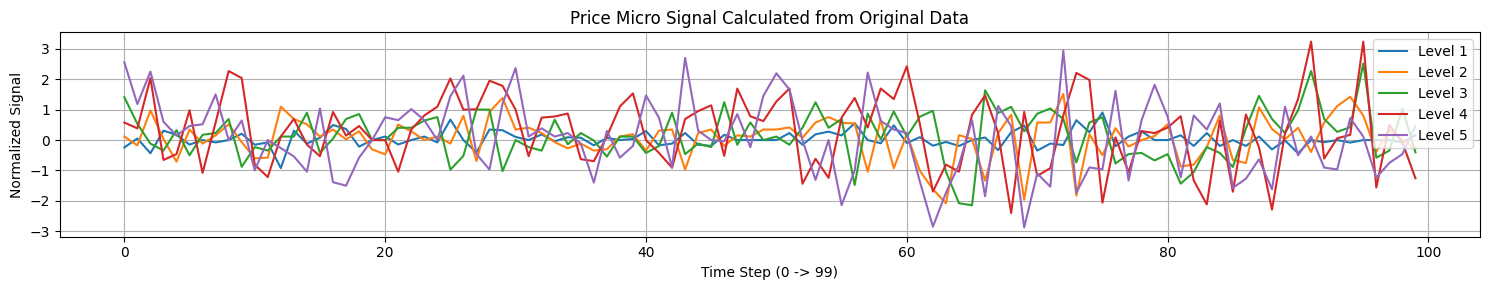

In [72]:
plt.figure(figsize=(15,3))
#plt.plot(price_micro_data, color = 'b')
for i in range(5):
    # i 从 0 到 4，对应第 1 到第 5 档
    plt.plot(price_micro_data[:, i], label=f'Level {i+1}')

plt.title('Price Micro Signal Calculated from Original Data')
plt.ylabel('Normalized Signal')
plt.grid(True)
plt.xlabel('Time Step (0 -> 99)')

plt.legend(loc='best') 

plt.tight_layout()
plt.show()

In [59]:
activations = {}
def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach().cpu().numpy()
    return hook

layer_name = 'conv_time4'
getattr(test_model, layer_name).register_forward_hook(get_activation('layer4_signal'))

test_model.eval()
inputs = torch.tensor(input_0521.values, dtype=torch.float32).unsqueeze(0)
inputs = inputs.to(device)

with torch.no_grad():
    _ = test_model(inputs)

signals = activations['layer4_signal']
print(f"Shape of signal: {signals.shape}")

Shape of signal: (1, 16, 100, 5)


In [60]:
_

tensor([[-1.1079, -0.3420,  0.4556]])

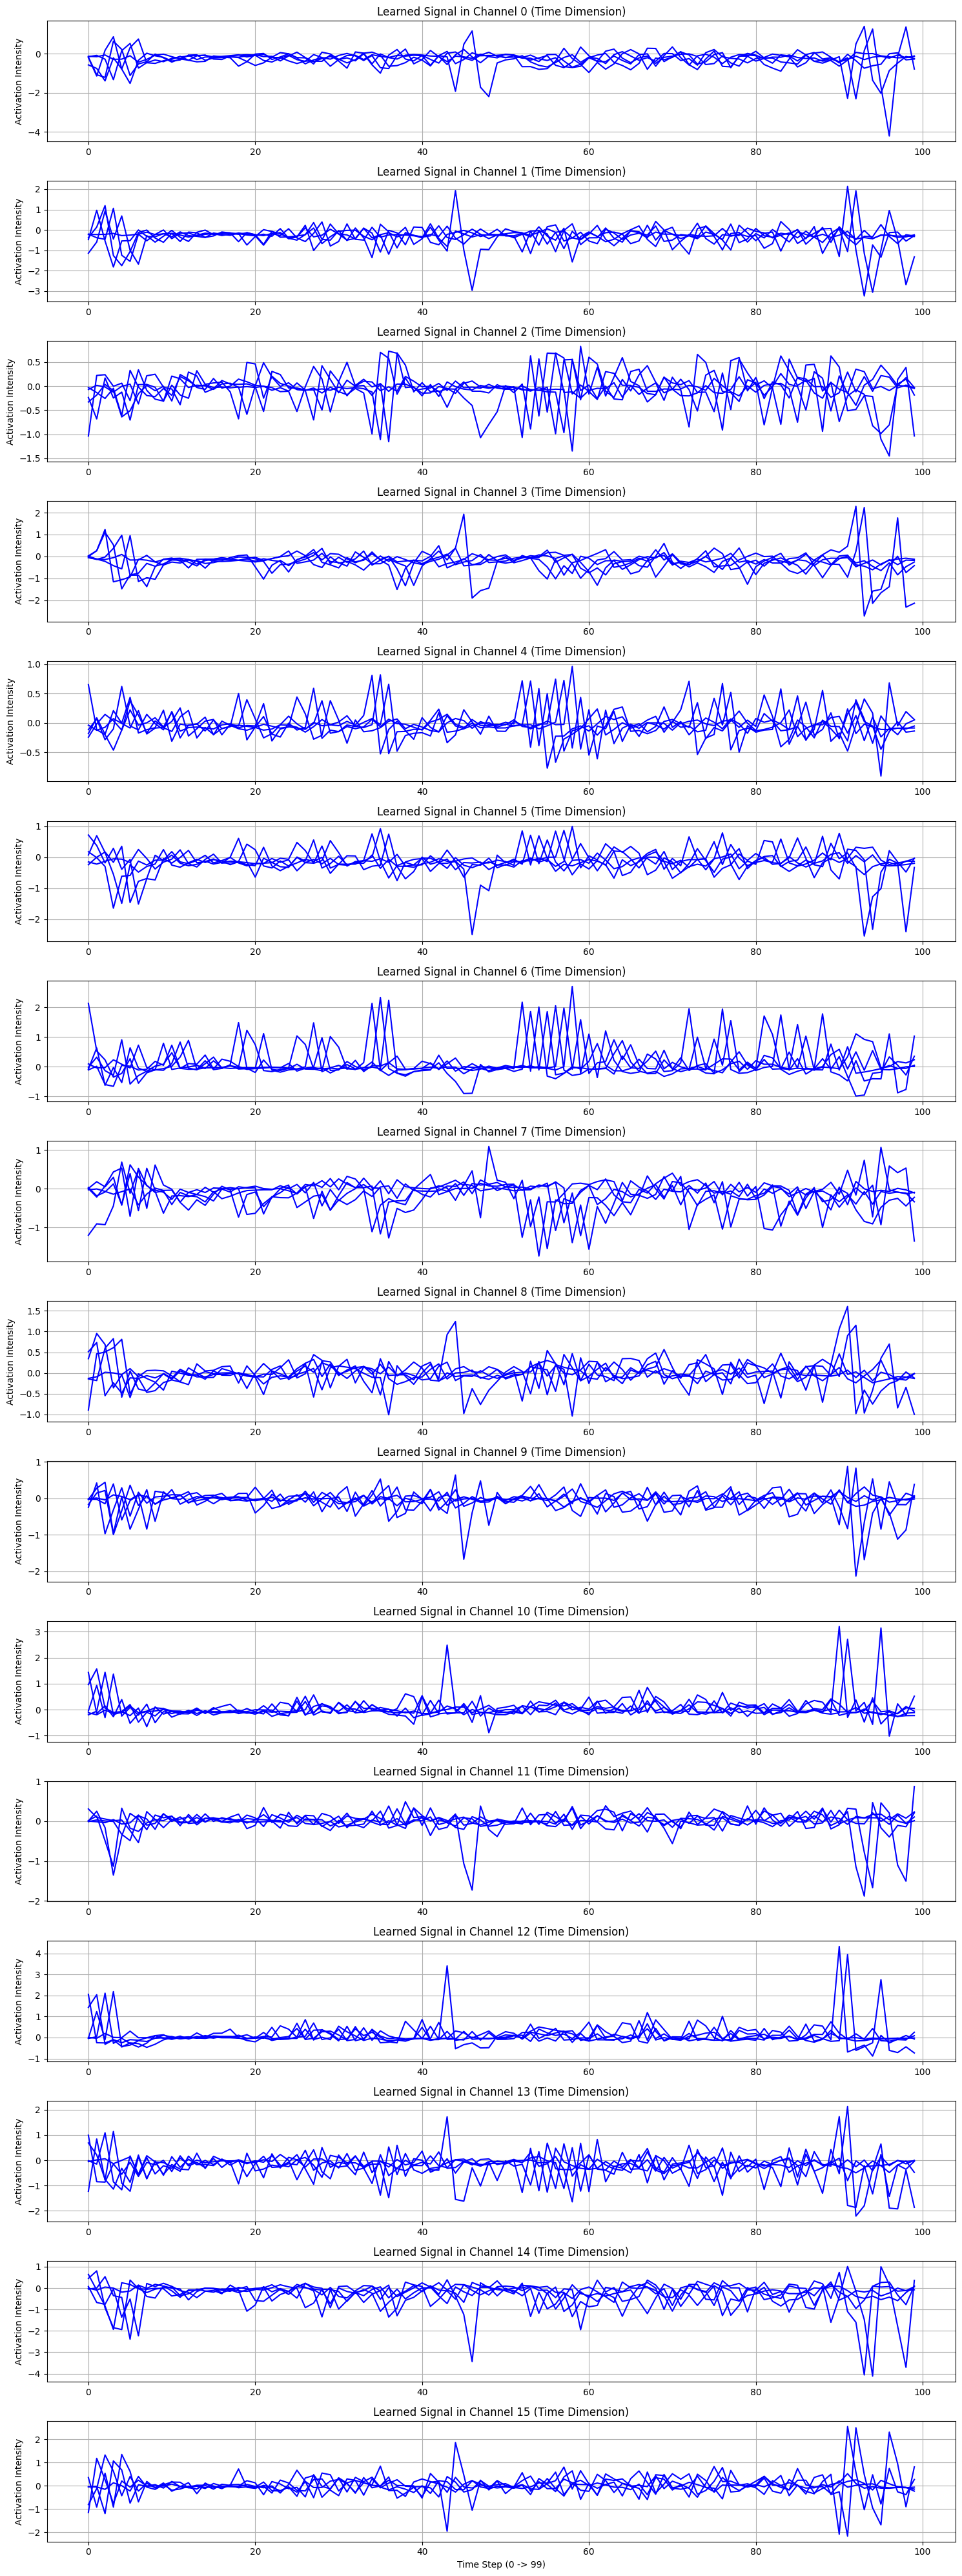

In [61]:
sample_idx = 0
num_channels_to_plot = 16

plt.figure(figsize=(15, 40))
for i in range(num_channels_to_plot):
    plt.subplot(num_channels_to_plot, 1, i + 1)
    
    # 提取第 i 个通道的 1D 时间序列信号
    channel_signal = signals[sample_idx, i, :, :].squeeze()
    
    plt.plot(channel_signal, label=f'Channel {i} Activation', color='b')
    plt.title(f'Learned Signal in Channel {i} (Time Dimension)')
    plt.ylabel('Activation Intensity')
    plt.grid(True)

plt.xlabel('Time Step (0 -> 99)')
plt.tight_layout()
plt.show()

In [ ]:
state_dict = test_model.state_dict()

for layer_name, param_tensor in state_dict.items():
    print(f"Layer: {layer_name} | Shape: {param_tensor.shape}")

Layer: conv_feat1.weight | Shape: torch.Size([16, 1, 1, 2])
Layer: conv_feat1.bias | Shape: torch.Size([16])
Layer: conv_time1.weight | Shape: torch.Size([16, 16, 4, 1])
Layer: conv_time1.bias | Shape: torch.Size([16])
Layer: conv_time2.weight | Shape: torch.Size([16, 16, 4, 1])
Layer: conv_time2.bias | Shape: torch.Size([16])
Layer: conv_feat2.weight | Shape: torch.Size([16, 16, 1, 2])
Layer: conv_feat2.bias | Shape: torch.Size([16])
Layer: conv_time3.weight | Shape: torch.Size([16, 16, 4, 1])
Layer: conv_time3.bias | Shape: torch.Size([16])
Layer: conv_time4.weight | Shape: torch.Size([16, 16, 4, 1])
Layer: conv_time4.bias | Shape: torch.Size([16])
Layer: conv_feat3.weight | Shape: torch.Size([16, 16, 1, 5])
Layer: conv_feat3.bias | Shape: torch.Size([16])
Layer: conv_time5.weight | Shape: torch.Size([16, 16, 4, 1])
Layer: conv_time5.bias | Shape: torch.Size([16])
Layer: conv_time6.weight | Shape: torch.Size([16, 16, 4, 1])
Layer: conv_time6.bias | Shape: torch.Size([16])
Layer: incp

In [65]:
state_dict = test_model.state_dict()

# 定义你需要提取的目标层名称
target_layers = [
    'conv_feat1', 'conv_time1', 'conv_time2', 
    'conv_feat2', 'conv_time3', 'conv_time4'
]

# 构建一个字典来存储提取出的 NumPy 数组
model_params = {}

for layer in target_layers:
    weight_key = f"{layer}.weight"
    bias_key = f"{layer}.bias"
    
    # 阻断梯度图，转移到 CPU，并转换为 numpy
    model_params[weight_key] = state_dict[weight_key].detach().cpu().numpy()
    model_params[bias_key] = state_dict[bias_key].detach().cpu().numpy()

feat1_weights = model_params['conv_feat1.weight']

print("--- Conv_feat1 空间融合核数值分析 ---")
# 遍历打印这 16 个底层滤波器的具体数值
for i in range(16):
    # 使用 squeeze 去除大小为 1 的维度，提取出核心的 2 个浮点数
    kernel_values = feat1_weights[i].squeeze() 
    
    # 输出这 2 个数值，这代表了网络赋予 Price 和 Size（或前后档位）的绝对相对权重
    print(f"Filter {i:02d}: w1={kernel_values[0]:.6f}, w2={kernel_values[1]:.6f}")

--- Conv_feat1 空间融合核数值分析 ---
Filter 00: w1=-0.054254, w2=-0.049207
Filter 01: w1=0.006149, w2=-0.026459
Filter 02: w1=0.028312, w2=-0.082582
Filter 03: w1=-0.053938, w2=-0.089749
Filter 04: w1=0.008489, w2=0.145801
Filter 05: w1=0.003816, w2=-0.013311
Filter 06: w1=0.025843, w2=0.155184
Filter 07: w1=-0.015798, w2=0.028125
Filter 08: w1=-0.004610, w2=-0.074927
Filter 09: w1=0.005999, w2=0.591130
Filter 10: w1=-0.004661, w2=-0.031327
Filter 11: w1=0.000999, w2=-0.104285
Filter 12: w1=-0.003849, w2=-0.145923
Filter 13: w1=-0.189363, w2=0.177533
Filter 14: w1=-0.044026, w2=-0.113658
Filter 15: w1=0.004690, w2=-0.002438


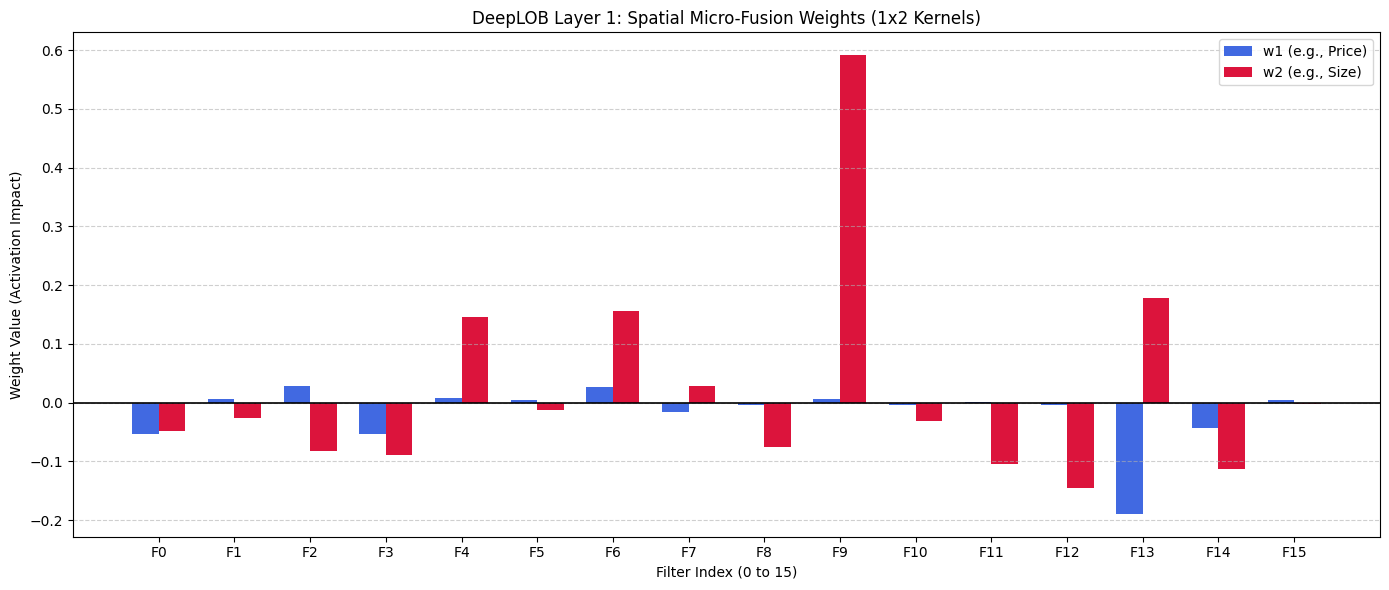

In [67]:
weights_2d = feat1_weights.squeeze() 

w1 = weights_2d[:, 0]
w2 = weights_2d[:, 1]
filters = np.arange(16)

plt.figure(figsize=(14, 6))
width = 0.35  # 柱子的宽度

# 绘制两组柱状图
plt.bar(filters - width/2, w1, width, label='w1 (e.g., Price)', color='royalblue')
plt.bar(filters + width/2, w2, width, label='w2 (e.g., Size)', color='crimson')

# 添加 0 轴基准线，方便看正负
plt.axhline(0, color='black', linewidth=1.2, linestyle='-')

plt.ylabel('Weight Value (Activation Impact)')
plt.xlabel('Filter Index (0 to 15)')
plt.title('DeepLOB Layer 1: Spatial Micro-Fusion Weights (1x2 Kernels)')
plt.xticks(filters, [f'F{i}' for i in filters])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()